In [1]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from hnet.synth import generate
from hnet.synth import utils 
from hnet.train.hnet import train_hnet

%load_ext autoreload
%autoreload 2

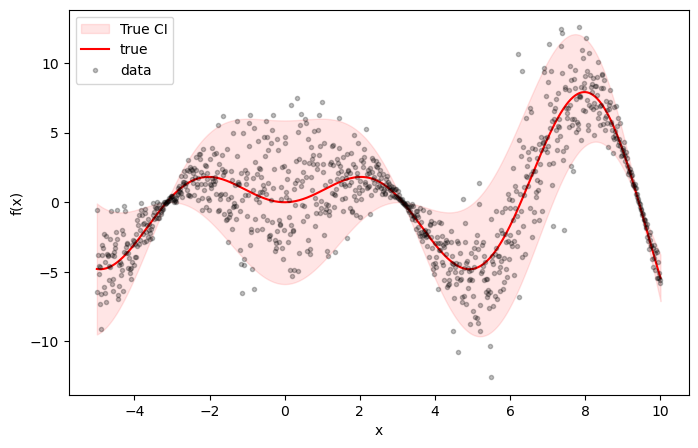

In [ ]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=1000, scale=3)

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

In [12]:
num_epochs = 50
samples = 100
batch_size = 250
lr = 1e-4
obj = 'edl'

hnet_kwargs = {'stochastic_channels':5, 
               'width':100, 
               'learn_pz':False, 
               'nvp_kwargs':{'hidden_dim':10, 
                             'num_layers':4, 
                             'nonlin':'relu', 
                             'mask_type':'alternating'}}

mlp_kwargs = {'hidden_channels':50, 
              'layers':2}


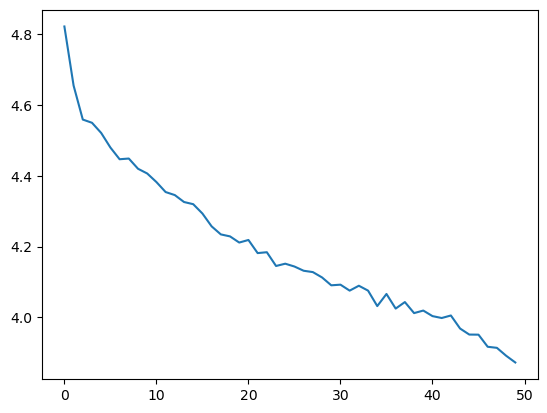

In [13]:

model, losses = train_hnet(x.view(-1,1),y.view(-1,1), loss_fn=obj, mlp_kwargs=mlp_kwargs, hnet_kwargs=hnet_kwargs,
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs)

plt.figure()
plt.plot(losses)
plt.show()

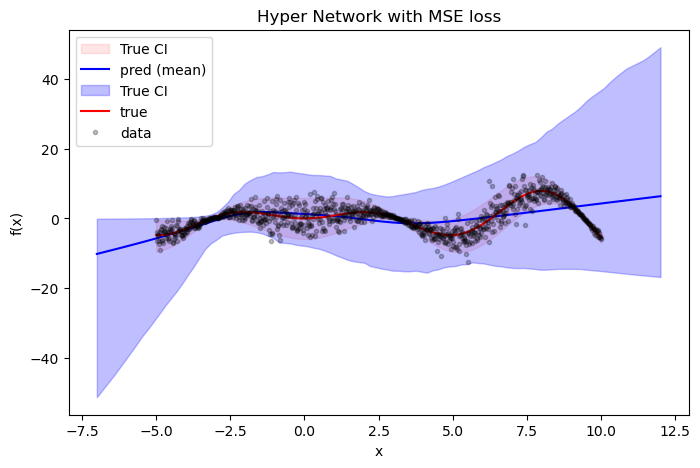

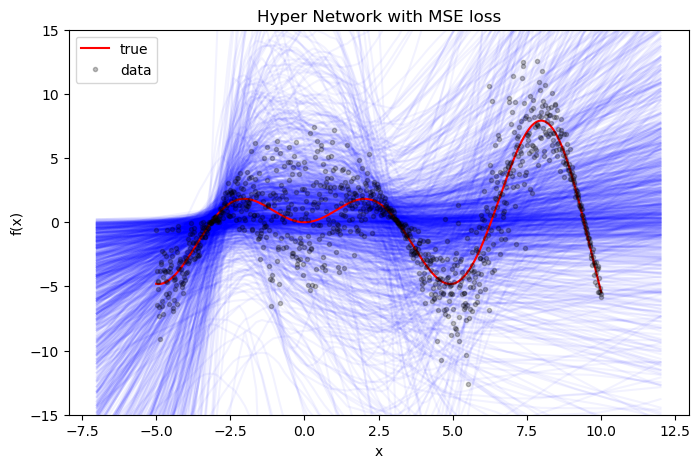

In [14]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='Hyper Network with MSE loss')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='Hyper Network with MSE loss', plot_ci=False, ylim=(-15,15))

In [15]:
mlp_kwargs = model_kwargs={'hidden_channels':hidden_channels, 
                           'layers':layers}

hnet_kwargs = {'stochastic_channels':gaussian_channels, 
               'width':width}

model, losses = train_hnet(x.view(-1,1),y.view(-1,1), loss_fn='nll', mlp_kwargs=mlp_kwargs, hnet_kwargs=hnet_kwargs,
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

NameError: name 'hidden_channels' is not defined

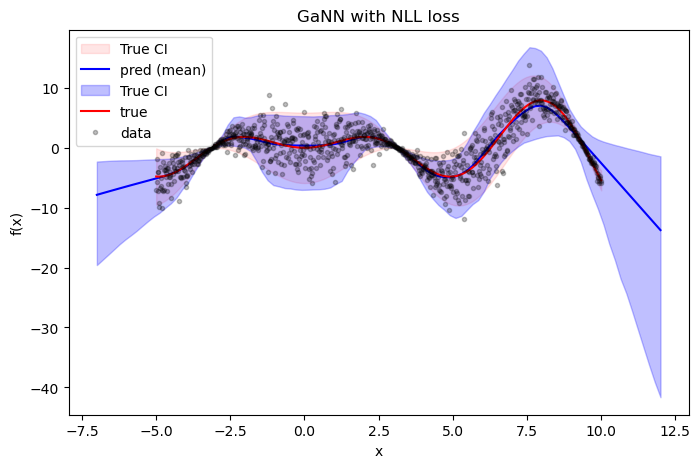

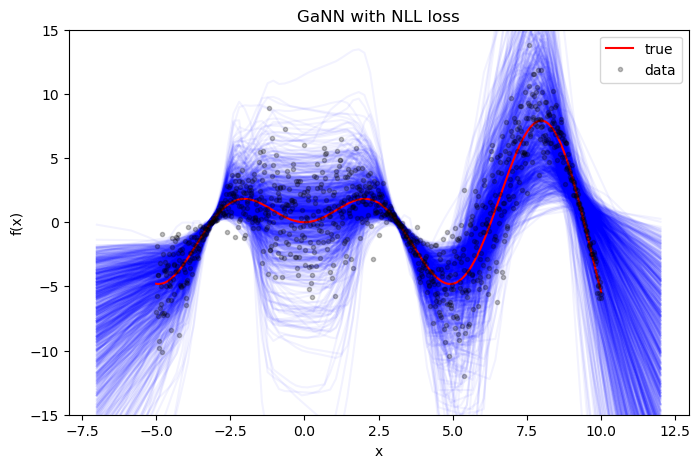

In [11]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with NLL loss')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with NLL loss', plot_ci=False, ylim=(-15,15))

In [7]:
# create a symmetric dataset, our method should effectively identify both local minimia 

# use val to select optimal performing z values. 

# quantify epistemic vs aleatoric - 
#   aleatoric = GaNN_MSE - GaNN_NLL
#   epistemic = GaNN_NLL ... ? 